In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\data\raw\Bengaluru_House_Data.csv")

In [3]:
print(df.shape)

(13320, 9)


In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df.drop(columns = ["society"], inplace = True)
print(df.columns.tolist())

['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony', 'price']


In [6]:
# dropping the rows with missing values
df.dropna(inplace = True)
print("shape after dropping missing values:", df.shape)

shape after dropping missing values: (12710, 8)


4.5% of our data is lost which is completely fine for a huge dataset

In [7]:
df["bhk"] = df["size"].apply(lambda x: int(x.split(" ")[0]))
print(df["bhk"].value_counts().head(10))

bhk
2     5480
3     4655
4     1238
1      648
5      299
6      192
7       85
8       68
9       34
11       3
Name: count, dtype: int64


In [8]:
# drop original size column
df.drop(columns = ["size"], inplace = True)
print(df.columns.tolist())

['area_type', 'availability', 'location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk']


In [9]:
#total_sqft column
df[~df["total_sqft"].apply(lambda x: str(x).replace(".", "").isnumeric())]["total_sqft"].head(20)

30         2100 - 2850
122        3067 - 8156
137        1042 - 1105
165        1145 - 1340
188        1015 - 1540
410     34.46Sq. Meter
549        1195 - 1440
661        1120 - 1145
672        3090 - 5002
772        1160 - 1195
775      1000Sq. Meter
850        1115 - 1130
886          520 - 645
927        1000 - 1285
959          650 - 665
990          633 - 666
1019         5.31Acres
1086           30Acres
1178       1445 - 1455
1183        884 - 1116
Name: total_sqft, dtype: str

we have 2 types of problematic values:
 - Ranges - we'll take avg of these 2 numbers
 - diff units sq.meter, Acres, etc..

In [10]:
def convert_sqft(x):
    tokens = x.split("-")
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2 
    try:
        return float(x)
    except: 
        return None
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
df = df.dropna(subset = ["total_sqft"])
print(df.shape)
print(df["total_sqft"].head(10))

(12668, 8)
0     1056.0
1     2600.0
2     1440.0
3     1521.0
4     1200.0
5     1170.0
8     1310.0
10    1800.0
11    2785.0
12    1000.0
Name: total_sqft, dtype: float64


In [11]:
# removing outliers
# considering that a single bedroom with atleast 300sqft
# example: 2BHK with 400sqft then 400/2 = 200sqft per bedroom- remove
# 2BHK with 800sqft then 800/2 = 400sqft per bedroom- keep 
df = df[df["total_sqft"] / df["bhk"] >= 300]
print("Shape:", df.shape)

Shape: (12013, 8)


In [12]:
#adding price per sqft column
df["price_per_sqft"] = round(df["price"]*100000 / df["total_sqft"], 2)
print(df["price_per_sqft"].describe())

count     12013.000000
mean       6206.082361
std        3985.518849
min         267.830000
25%        4199.360000
50%        5252.530000
75%        6823.530000
max      176470.590000
Name: price_per_sqft, dtype: float64


In [13]:
# removing price per sqft outliers per location
def remove_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby("location"):
        m = np.mean(subdf["price_per_sqft"])
        st = np.std(subdf["price_per_sqft"])
        reduced_df = subdf[(subdf["price_per_sqft"] > (m - st)) & (subdf["price_per_sqft"] <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df = remove_outliers(df)
print("Shape:", df.shape)

Shape: (8920, 9)


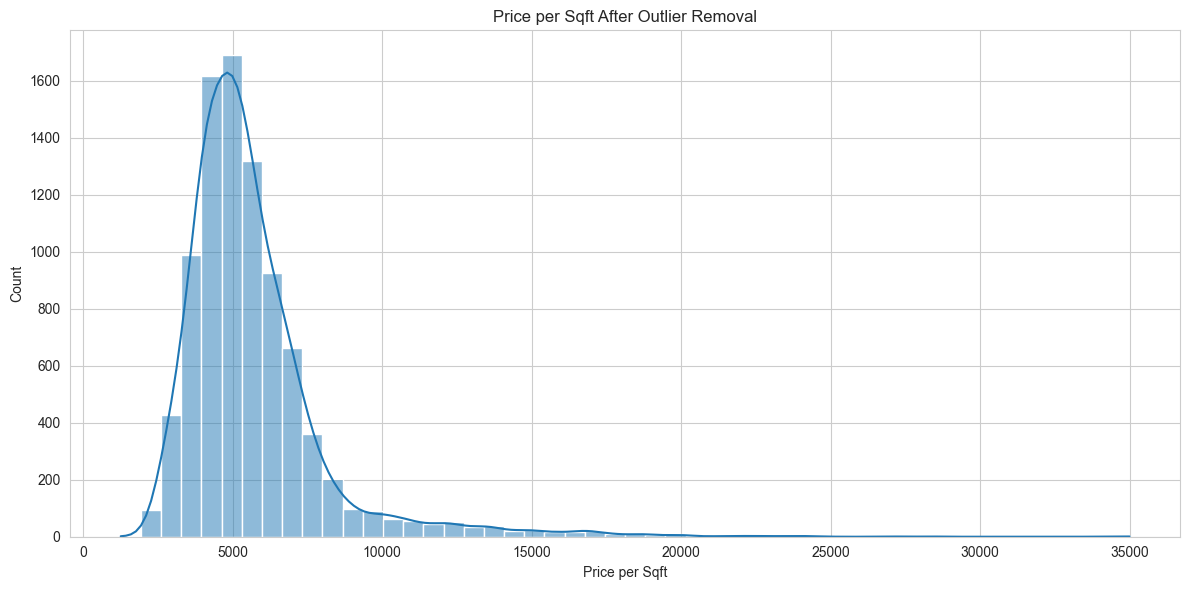

In [17]:
plt.figure(figsize=(12, 6))
sns.histplot(df["price_per_sqft"], bins=50, kde=True)
plt.title("Price per Sqft After Outlier Removal")
plt.xlabel("Price per Sqft")
plt.ylabel("Count")
plt.tight_layout()

In [14]:
# removing bathroom outliers
print(df[df["bath"] > df["bhk"] + 2]["bath"].value_counts())
df = df[df["bath"] <= df["bhk"] + 2]
print(df.shape)

bath
7.0    1
9.0    1
6.0    1
Name: count, dtype: int64
(8917, 9)


In [15]:
# droping unnecessary columns
df.drop(columns = ["availability","area_type","balcony"], inplace = True)
print(df.columns.tolist())

['location', 'total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft']


In [16]:
df.to_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\data\processed\cleaned_data.csv", index=False)
print("Cleaned data saved successfully!")
print("Final shape:", df.shape)

Cleaned data saved successfully!
Final shape: (8917, 6)
